## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import csv
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import re
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_percentage_error, r2_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', None)

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load Dataset

In [2]:
dataset = r"all_upi_cleaned.csv"

df = pd.read_csv(
    dataset,
    encoding="latin1",
    engine="python",
    on_bad_lines="skip"
)

# Normalise column names: strip whitespace to avoid silent key-miss errors
df.columns = df.columns.str.strip()

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (52017, 17)


,village,province,district,sector,cell,upi,x,y,area_in_meter_square,zoning,zoning_percentage,sentlement,sentlement_percentage,Land_Use,Minimum_Value_Per_Sqm,Weighted_Average_Value_Per_Sqm,Maximum_Value_Per_Sqm
0,Ngobagoba,Southern,Huye,Huye,Sovu,2/04/02/04/1703,"465,576.84","4,717,872.35",199.76,A1-Agriculture zone: 201.53 mÂ²,100.00,Rural Settlement,0.00,Farm land,702.00,"2,230.00","9,061.00"
1,Kigwene,Southern,Huye,Mbazi,Tare,2/04/07/07/2549,"465,043.57","4,719,728.83",628.41,F1-Forest plantation zone: 378.26 mÂ²,59.70,Not within settlement boundaries,0.00,plantation,292.00,"1,650.00","3,913.00"
2,Gatongati,Southern,Huye,Huye,Nyakagezi,2/04/02/02/5243,"463,790.00","4,714,615.93",598.39,A1-Agriculture zone: 528.91 mÂ²,87.60,Not within settlement boundaries,0.00,Farm land,343.00,"1,857.00","6,500.00"
3,Nyarutovu,Southern,Huye,Huye,Muyogoro,2/04/02/01/2877,"465,627.64","4,711,902.83",612.14,F1-Forest plantation zone: 617.63 mÂ²,100.00,Not within settlement boundaries,0.00,plantation,438.00,"1,517.00","5,623.00"
4,Gakombe,Southern,Huye,Mbazi,Kabuga,2/04/07/02/687,"470,297.05","4,716,622.06",111.97,R1B-Rural residential zone: 112.51 mÂ²,99.60,Rural Settlement,100.00,residential,458.00,"1,654.00","5,232.00"


## 3. Data Cleaning & Feature Engineering

In [3]:
# ── 3a. Drop rows missing price columns (targets) ───────────────────────────
price_cols = ['Minimum_Value_Per_Sqm', 'Weighted_Average_Value_Per_Sqm', 'Maximum_Value_Per_Sqm']

# Convert price/area columns to numeric BEFORE the dropna so non-numeric
# values (e.g. stray text) do not silently survive as strings.
for col in price_cols + ['area_in_meter_square']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=price_cols + ['area_in_meter_square'])

# Drop rows where area is zero or negative – they would break price × area math
df = df[df['area_in_meter_square'] > 0]

print(f"Shape after dropping rows with missing/invalid price/area: {df.shape}")


# ── 3b. Normalize Land_Use ───────────────────────────────────────────────────
def normalize_land_use(s):
    if pd.isna(s):
        return 'unknown'
    s = str(s).lower().strip().lstrip('|').strip()
    if any(x in s for x in ['farm', 'agricultur', 'agri']): return 'agriculture'
    if 'plantation' in s: return 'plantation'
    if 'forest'     in s: return 'forest'
    if 'wetland'    in s: return 'wetland'
    if 'commercial' in s: return 'commercial'
    if 'industrial' in s: return 'industrial'
    if 'road'       in s: return 'road'
    if 'mixed'      in s: return 'mixed_use'
    if 'residential'in s: return 'residential'
    return 'other'

df['land_use_clean'] = df['Land_Use'].apply(normalize_land_use)


# ── 3c. Extract zone code from zoning ────────────────────────────────────────
def extract_zone_code(z):
    if pd.isna(z):
        return 'Unknown'
    m = re.match(r'^([A-Z0-9]+)', str(z).strip())
    return m.group(1) if m else 'Unknown'

df['zone_code'] = df['zoning'].apply(extract_zone_code)


# ── 3d. Normalize settlement ─────────────────────────────────────────────────
def normalize_settlement(s):
    if pd.isna(s):
        return 'not_found'
    s = str(s).lower().strip()
    if 'secondary' in s or 'second' in s: return 'secondary_city'
    if 'rural'     in s or 'rular'  in s: return 'rural_settlement'
    if 'plantation'in s:                  return 'plantation'
    return 'not_found'

df['settlement_clean'] = df['sentlement'].apply(normalize_settlement)


# ── 3e. Normalize village & cell (fill NaN before strip) ─────────────────────
# Using fillna('unknown') prevents AttributeError on .str.lower() when NaNs exist
df['village_clean'] = df['village'].fillna('unknown').str.lower().str.strip()
df['cell_clean']    = df['cell'].fillna('unknown').str.lower().str.strip()


print("Cleaning done!")
print("land_use_clean :", df['land_use_clean'].value_counts().to_dict())
print("zone_code top  :", df['zone_code'].value_counts().head(5).to_dict())
print("settlement_clean:", df['settlement_clean'].value_counts().to_dict())

Shape after dropping rows with missing/invalid price/area: (51955, 17)
Cleaning done!
land_use_clean : {'agriculture': 23383, 'residential': 15557, 'plantation': 6141, 'wetland': 4897, 'commercial': 1571, 'industrial': 237, 'other': 77, 'road': 43, 'forest': 41, 'unknown': 7, 'mixed_use': 1}
zone_code top  : {'A1': 23269, 'R1B': 8243, 'F1': 6230, 'R3': 3325, 'W3': 2467}
settlement_clean: {'not_found': 23377, 'secondary_city': 18920, 'rural_settlement': 9657, 'plantation': 1}


## 4. Remove Outliers

In [4]:
outlier_cols = [
    'area_in_meter_square',
    'Minimum_Value_Per_Sqm',
    'Weighted_Average_Value_Per_Sqm',
    'Maximum_Value_Per_Sqm',
    'zoning_percentage',
    'sentlement_percentage',
]

# price/area already converted in §3a; convert the percentage cols here
for col in ['zoning_percentage', 'sentlement_percentage']:
    df[col] = pd.to_numeric(df[col], errors='coerce')


def remove_outliers_iqr(df, column, iqr_multiplier=3.0):
    """Remove rows outside [Q1 - k·IQR, Q3 + k·IQR]; NaN rows are also dropped."""
    df = df.dropna(subset=[column])
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - iqr_multiplier * IQR
    upper = Q3 + iqr_multiplier * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]


for col in outlier_cols:
    before = len(df)
    df = remove_outliers_iqr(df, col)
    print(f"{col}: removed {before - len(df)} rows → {len(df)} remaining")

print(f"\nFinal shape after outlier removal: {df.shape}")

area_in_meter_square: removed 3171 rows → 48784 remaining
Minimum_Value_Per_Sqm: removed 4837 rows → 43947 remaining
Weighted_Average_Value_Per_Sqm: removed 6204 rows → 37743 remaining
Maximum_Value_Per_Sqm: removed 908 rows → 36835 remaining
zoning_percentage: removed 1308 rows → 35527 remaining
sentlement_percentage: removed 16 rows → 35511 remaining

Final shape after outlier removal: (35511, 22)


## 5. Fill Remaining Missing Values

In [5]:
# Use df[col] = df[col].fillna(...)  — avoids the pandas
# SettingWithCopyWarning that arises from chained .fillna(inplace=True).
for col in ['zoning_percentage', 'sentlement_percentage', 'x', 'y']:
    df[col] = df[col].fillna(df[col].median())

print("Missing values filled!")
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("No missing values remaining in key columns.")
else:
    print(missing)

Missing values filled!
Land_Use    2
dtype: int64


## 6. Encode Categorical Features

In [6]:
label_encoders = {}

cat_cols = ['land_use_clean', 'zone_code', 'settlement_clean', 'village_clean', 'cell_clean']

for col in cat_cols:
    le = LabelEncoder()
    # Ensure no NaN reaches the encoder (convert any remaining to string 'nan')
    df[col + '_enc'] = le.fit_transform(df[col].fillna('unknown').astype(str))
    label_encoders[col] = le

print("Encoding done!")
print("Encoded columns:", [c + '_enc' for c in cat_cols])

Encoding done!
Encoded columns: ['land_use_clean_enc', 'zone_code_enc', 'settlement_clean_enc', 'village_clean_enc', 'cell_clean_enc']


## 7. Define Features and Targets

> **Key fix:** We predict `Price_Per_Sqm` (Min, Avg, Max) and then multiply by area at
> prediction time. This keeps targets in a smaller, model-friendly range and gives
> accurate total-value estimates.

In [7]:
Y = df[['Minimum_Value_Per_Sqm',
        'Weighted_Average_Value_Per_Sqm',
        'Maximum_Value_Per_Sqm']].copy()

feature_cols = [
    'x', 'y',
    'area_in_meter_square',
    'zoning_percentage',
    'sentlement_percentage',
    'land_use_clean_enc',
    'zone_code_enc',
    'settlement_clean_enc',
    'village_clean_enc',
    'cell_clean_enc',
]

X = df[feature_cols].copy()

# Defensive: ensure no NaN reaches the scaler/model
assert X.isnull().sum().sum() == 0, "NaN values still present in X – check earlier steps!"
assert Y.isnull().sum().sum() == 0, "NaN values still present in Y – check earlier steps!"

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"\nFeatures: {feature_cols}")
print(f"\nY stats:")
print(Y.describe())

X shape: (35511, 10)
Y shape: (35511, 3)

Features: ['x', 'y', 'area_in_meter_square', 'zoning_percentage', 'sentlement_percentage', 'land_use_clean_enc', 'zone_code_enc', 'settlement_clean_enc', 'village_clean_enc', 'cell_clean_enc']

Y stats:
       Minimum_Value_Per_Sqm  Weighted_Average_Value_Per_Sqm  \
count              35,511.00                       35,511.00   
mean                  423.17                        1,914.04   
std                   112.18                          270.15   
min                   149.00                          938.00   
25%                   359.00                        1,704.00   
50%                   399.00                        1,913.00   
75%                   465.00                        2,121.00   
max                 1,506.00                        3,389.00   

       Maximum_Value_Per_Sqm  
count              35,511.00  
mean                5,328.66  
std                 1,018.11  
min                 1,517.00  
25%                 4,8

## 8. Train/Test Split & Scaling

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save scaler immediately so it is available even if later cells fail
joblib.dump(scaler, 'scaler.pkl')

print(f"Train set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")
print("Scaler saved as scaler.pkl")

Train set: (28408, 10)
Test set:  (7103, 10)
Scaler saved as scaler.pkl


## 9. Define Models

In [9]:
models = [
    ("Linear Regression", LinearRegression()),
    ("Decision Tree",     DecisionTreeRegressor(random_state=RANDOM_STATE)),
    ("Random Forest",     RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
    ("KNN",               KNeighborsRegressor(n_neighbors=5)),
    ("ANN / MLP",         MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_STATE)),
]
print("Models defined!")

Models defined!


## 10. Training & Evaluation Function

In [10]:
def train_evaluate_model(name, model, X_train, X_test, Y_train, Y_test):
    """
    Train *model* and return (fitted_model, metrics_dict).

    RandomForest and MLP natively support multi-output regression;
    the remaining estimators are wrapped with MultiOutputRegressor.
    """
    start_time = time.time()

    if name in ["Linear Regression", "Decision Tree", "KNN"]:
        model = MultiOutputRegressor(model)

    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)

    elapsed = time.time() - start_time

    return model, {
        "Model":        name,
        "MAPE_Min":     mean_absolute_percentage_error(Y_test.iloc[:, 0], Y_pred[:, 0]) * 100,
        "MAPE_Avg":     mean_absolute_percentage_error(Y_test.iloc[:, 1], Y_pred[:, 1]) * 100,
        "MAPE_Max":     mean_absolute_percentage_error(Y_test.iloc[:, 2], Y_pred[:, 2]) * 100,
        "R2_Min":       r2_score(Y_test.iloc[:, 0], Y_pred[:, 0]),
        "R2_Avg":       r2_score(Y_test.iloc[:, 1], Y_pred[:, 1]),
        "R2_Max":       r2_score(Y_test.iloc[:, 2], Y_pred[:, 2]),
        "Time_Seconds": elapsed,
    }

print("Training function ready!")

Training function ready!


## 11. Train All Models

In [11]:
results        = []
trained_models = {}

for name, model in models:
    print(f"Training {name}...")
    trained_model, res = train_evaluate_model(
        name, model, X_train_scaled, X_test_scaled, Y_train, Y_test
    )
    results.append(res)
    trained_models[name] = trained_model
    print(f"  Done in {res['Time_Seconds']:.1f}s | R2_Avg={res['R2_Avg']:.4f} | MAPE_Avg={res['MAPE_Avg']:.2f}%")

print("\n All models trained!")

Training Linear Regression...
  Done in 0.1s | R2_Avg=0.2272 | MAPE_Avg=10.06%
Training Decision Tree...
  Done in 0.9s | R2_Avg=0.9322 | MAPE_Avg=0.69%
Training Random Forest...
  Done in 2.6s | R2_Avg=0.9585 | MAPE_Avg=0.76%
Training KNN...
  Done in 1.4s | R2_Avg=0.8773 | MAPE_Avg=2.06%
Training ANN / MLP...
  Done in 175.3s | R2_Avg=0.7777 | MAPE_Avg=5.16%

✅ All models trained!


## 12. Results

In [12]:
results_df = pd.DataFrame(results)
results_df["R2_Mean"]   = results_df[["R2_Min",   "R2_Avg",   "R2_Max"]].mean(axis=1)
results_df["MAPE_Mean"] = results_df[["MAPE_Min", "MAPE_Avg", "MAPE_Max"]].mean(axis=1)

print("\n Model Performance (sorted by R2_Mean):\n")
display(results_df.sort_values(by="R2_Mean", ascending=False))


 Model Performance (sorted by R2_Mean):



,Model,MAPE_Min,MAPE_Avg,MAPE_Max,R2_Min,R2_Avg,R2_Max,Time_Seconds,R2_Mean,MAPE_Mean
2,Random Forest,1.65,0.76,1.84,0.93,0.96,0.90,2.59,0.93,1.42
1,Decision Tree,1.46,0.69,1.78,0.89,0.93,0.81,0.86,0.88,1.31
3,KNN,4.00,2.06,3.04,0.85,0.88,0.83,1.36,0.85,3.03
4,ANN / MLP,12.80,5.16,4.54,0.59,0.78,0.82,175.30,0.73,7.50
0,Linear Regression,18.16,10.06,14.34,0.18,0.23,0.19,0.07,0.20,14.19


## 13. Visualise Model Performance

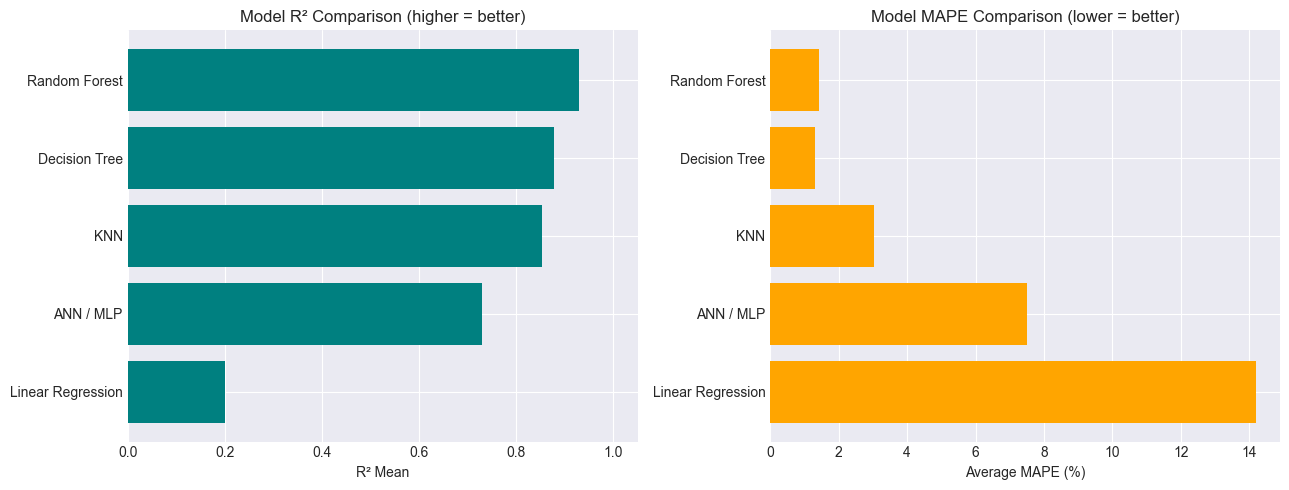

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sorted_df = results_df.sort_values("R2_Mean")

axes[0].barh(sorted_df['Model'], sorted_df['R2_Mean'], color='teal')
axes[0].set_xlabel('R² Mean')
axes[0].set_title('Model R² Comparison (higher = better)')
axes[0].set_xlim(0, 1.05)

axes[1].barh(sorted_df['Model'], sorted_df['MAPE_Mean'], color='orange')
axes[1].set_xlabel('Average MAPE (%)')
axes[1].set_title('Model MAPE Comparison (lower = better)')

plt.tight_layout()
plt.show()

## 14. Select & Save Best Model

In [14]:
best_idx        = results_df['R2_Mean'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']

print(f"Best model selected : {best_model_name}")
print(f"R2 Mean             : {results_df.loc[best_idx, 'R2_Mean']:.4f}")
print(f"MAPE Mean           : {results_df.loc[best_idx, 'MAPE_Mean']:.2f}%")

selected_model = trained_models[best_model_name]

# Refit on the full dataset so predictions at deploy time use all available data
X_scaled_full = scaler.transform(X)
selected_model.fit(X_scaled_full, Y)

joblib.dump(selected_model, 'best_land_price_model.pkl')
joblib.dump(scaler,         'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
with open('features.json', 'w') as f:
    json.dump(feature_cols, f)

print("\n Saved successfully:")
for fname in ['best_land_price_model.pkl', 'scaler.pkl', 'label_encoders.pkl', 'features.json']:
    print(f"   - {fname}")

Best model selected : Random Forest
R2 Mean             : 0.9303
MAPE Mean           : 1.42%

 Saved successfully:
   - best_land_price_model.pkl
   - scaler.pkl
   - label_encoders.pkl
   - features.json


## 15. Load Saved Model

In [15]:
model          = joblib.load('best_land_price_model.pkl')
label_encoders = joblib.load('label_encoders.pkl')
scaler         = joblib.load('scaler.pkl')
with open('features.json') as f:
    features = json.load(f)

print("Model, scaler, encoders and feature list loaded successfully!")

Model, scaler, encoders and feature list loaded successfully!


## 16. Predict by UPI

> The model predicts **Price per m²** (Min, Avg, Max), then multiplies by
> `area_in_meter_square` to obtain total values. Unseen categorical values
> (villages / cells not in training data) are gracefully mapped to a
> dedicated `'__unknown__'` class rather than raising a `ValueError`.

In [16]:
def safe_encode(series, le):
    """
    Transform *series* with *le* (a fitted LabelEncoder).
    Categories not seen during training are mapped to a special
    '__unknown__' bucket so prediction never crashes at runtime.
    """
    known = set(le.classes_)
    mapped = series.astype(str).where(series.astype(str).isin(known), other='__unknown__')

    # Extend the encoder's class list once if '__unknown__' is new
    if '__unknown__' not in known:
        le.classes_ = np.append(le.classes_, '__unknown__')

    return le.transform(mapped)


def predict_by_upi(upi_list, show_all_columns=False):
    """
    Predict total land values for a list (or single string) of UPI codes.

    Parameters
    ----------
    upi_list : str | list[str]
    show_all_columns : bool
        If True, return the full dataframe; otherwise return a focused
        display subset.

    Returns
    -------
    pd.DataFrame  (empty DataFrame if no UPI matched)
    """
    if isinstance(upi_list, str):
        upi_list = [upi_list]
    upi_list = [str(u).strip() for u in upi_list]

    upi_rows = df[df['upi'].isin(upi_list)].copy()

    if upi_rows.empty:
        print("  No matching UPIs found.")
        print(f"   Searched for : {upi_list}")
        print(f"   Sample UPIs  : {df['upi'].head(10).tolist()}")
        return pd.DataFrame()

    print(f" Found {len(upi_rows)} matching UPI(s)")

    # Re-encode categoricals using safe_encode to handle unseen labels
    cat_cols = ['land_use_clean', 'zone_code', 'settlement_clean', 'village_clean', 'cell_clean']
    for col in cat_cols:
        upi_rows[col + '_enc'] = safe_encode(upi_rows[col].fillna('unknown'), label_encoders[col])

    X_upi = upi_rows[features].copy()

    # Guard against NaN in feature matrix
    if X_upi.isnull().any().any():
        print("  NaN values detected in feature matrix – filling with column medians.")
        X_upi = X_upi.fillna(X_upi.median())

    X_upi_scaled   = scaler.transform(X_upi)
    y_pred_per_sqm = model.predict(X_upi_scaled)   # shape (n, 3)

    area = upi_rows['area_in_meter_square'].values

    result_df = upi_rows.copy()

    # Per-sqm predictions
    result_df['Pred_Min_Per_Sqm'] = y_pred_per_sqm[:, 0]
    result_df['Pred_Avg_Per_Sqm'] = y_pred_per_sqm[:, 1]
    result_df['Pred_Max_Per_Sqm'] = y_pred_per_sqm[:, 2]

    # Total value = price/sqm × area
    result_df['Total_Min_Predicted'] = y_pred_per_sqm[:, 0] * area
    result_df['Total_Avg_Predicted'] = y_pred_per_sqm[:, 1] * area
    result_df['Total_Max_Predicted'] = y_pred_per_sqm[:, 2] * area

    # Actual totals for comparison
    result_df['Total_Min_Actual'] = result_df['Minimum_Value_Per_Sqm']          * area
    result_df['Total_Avg_Actual'] = result_df['Weighted_Average_Value_Per_Sqm'] * area
    result_df['Total_Max_Actual'] = result_df['Maximum_Value_Per_Sqm']          * area

    if show_all_columns:
        return result_df

    display_cols = [
        'upi', 'village', 'cell', 'area_in_meter_square', 'land_use_clean',
        'Minimum_Value_Per_Sqm',          'Pred_Min_Per_Sqm',
        'Weighted_Average_Value_Per_Sqm', 'Pred_Avg_Per_Sqm',
        'Maximum_Value_Per_Sqm',          'Pred_Max_Per_Sqm',
        'Total_Min_Actual',  'Total_Min_Predicted',
        'Total_Avg_Actual',  'Total_Avg_Predicted',
        'Total_Max_Actual',  'Total_Max_Predicted',
    ]
    display_cols = [c for c in display_cols if c in result_df.columns]
    return result_df[display_cols]

print(" Prediction function ready!")

 Prediction function ready!


## 17. Sample Predictions

In [17]:
example_upis = df['upi'].head(5).tolist()
print(f" Predicting for {len(example_upis)} UPIs...\n")
predicted_results = predict_by_upi(example_upis)
print("\n Prediction Results:")
display(predicted_results)

 Predicting for 5 UPIs...

 Found 6 matching UPI(s)

 Prediction Results:


,upi,village,cell,area_in_meter_square,land_use_clean,Minimum_Value_Per_Sqm,Pred_Min_Per_Sqm,Weighted_Average_Value_Per_Sqm,Pred_Avg_Per_Sqm,Maximum_Value_Per_Sqm,Pred_Max_Per_Sqm,Total_Min_Actual,Total_Min_Predicted,Total_Avg_Actual,Total_Avg_Predicted,Total_Max_Actual,Total_Max_Predicted
0,2/04/02/04/1703,Ngobagoba,Sovu,199.76,agriculture,702.00,699.56,"2,230.00","2,224.24","9,061.00","9,022.71","140,231.52","139,744.11","445,464.80","444,314.18","1,810,025.36","1,802,376.55"
1,2/04/07/07/2549,Kigwene,Tare,628.41,plantation,292.00,292.00,"1,650.00","1,650.00","3,913.00","3,913.00","183,495.72","183,495.72","1,036,876.50","1,036,876.50","2,458,968.33","2,458,968.33"
2,2/04/02/02/5243,Gatongati,Nyakagezi,598.39,agriculture,343.00,343.00,"1,857.00","1,857.00","6,500.00","6,500.00","205,247.77","205,247.77","1,111,210.23","1,111,210.23","3,889,535.00","3,889,535.00"
3,2/04/02/01/2877,Nyarutovu,Muyogoro,612.14,plantation,438.00,438.00,"1,517.00","1,517.00","5,623.00","5,623.00","268,117.32","268,117.32","928,616.38","928,616.38","3,442,063.22","3,442,063.22"
4,2/04/07/02/687,Gakombe,Kabuga,111.97,residential,458.00,458.00,"1,654.00","1,654.00","5,232.00","5,232.00","51,282.26","51,282.26","185,198.38","185,198.38","585,827.04","585,827.04"
369,2/04/02/04/1703,Ngobagoba,Sovu,199.76,agriculture,702.00,699.56,"2,230.00","2,224.24","9,061.00","9,022.71","140,231.52","139,744.11","445,464.80","444,314.18","1,810,025.36","1,802,376.55"


## 18. Single UPI Detailed Summary

In [18]:
single_upi    = df['upi'].iloc[0]
print(f" Predicting for UPI: {single_upi}\n")
single_result = predict_by_upi(single_upi)
display(single_result)

if not single_result.empty:
    area = single_result['area_in_meter_square'].iloc[0]
    print(f"\n Summary for UPI: {single_upi}")
    print(f"   Area: {area:,.2f} m²")
    print()
    header = f"   {'':30s} {'Actual':>15}  {'Predicted':>15}  {'Diff %':>10}"
    print(header)
    print(f"   {'-' * 75}")
    for label, act_col, pred_col in [
        ('Price/Sqm Min', 'Minimum_Value_Per_Sqm',          'Pred_Min_Per_Sqm'),
        ('Price/Sqm Avg', 'Weighted_Average_Value_Per_Sqm', 'Pred_Avg_Per_Sqm'),
        ('Price/Sqm Max', 'Maximum_Value_Per_Sqm',          'Pred_Max_Per_Sqm'),
    ]:
        if act_col in single_result.columns and pred_col in single_result.columns:
            act  = single_result[act_col].iloc[0]
            pred = single_result[pred_col].iloc[0]
            diff = abs(pred - act) / act * 100 if act != 0 else float('nan')
            print(f"   {label:30s} {act:>15,.2f}  {pred:>15,.2f}  {diff:>9.1f}%")
    print()
    for label, act_col, pred_col in [
        ('Total Min Value (RWF)', 'Total_Min_Actual', 'Total_Min_Predicted'),
        ('Total Avg Value (RWF)', 'Total_Avg_Actual', 'Total_Avg_Predicted'),
        ('Total Max Value (RWF)', 'Total_Max_Actual', 'Total_Max_Predicted'),
    ]:
        print(f"   {label:30s} {single_result[act_col].iloc[0]:>15,.2f}  {single_result[pred_col].iloc[0]:>15,.2f}")

 Predicting for UPI: 2/04/02/04/1703

 Found 2 matching UPI(s)


,upi,village,cell,area_in_meter_square,land_use_clean,Minimum_Value_Per_Sqm,Pred_Min_Per_Sqm,Weighted_Average_Value_Per_Sqm,Pred_Avg_Per_Sqm,Maximum_Value_Per_Sqm,Pred_Max_Per_Sqm,Total_Min_Actual,Total_Min_Predicted,Total_Avg_Actual,Total_Avg_Predicted,Total_Max_Actual,Total_Max_Predicted
0,2/04/02/04/1703,Ngobagoba,Sovu,199.76,agriculture,702.00,699.56,"2,230.00","2,224.24","9,061.00","9,022.71","140,231.52","139,744.11","445,464.80","444,314.18","1,810,025.36","1,802,376.55"
369,2/04/02/04/1703,Ngobagoba,Sovu,199.76,agriculture,702.00,699.56,"2,230.00","2,224.24","9,061.00","9,022.71","140,231.52","139,744.11","445,464.80","444,314.18","1,810,025.36","1,802,376.55"



 Summary for UPI: 2/04/02/04/1703
   Area: 199.76 m²

                                           Actual        Predicted      Diff %
   ---------------------------------------------------------------------------
   Price/Sqm Min                           702.00           699.56        0.3%
   Price/Sqm Avg                         2,230.00         2,224.24        0.3%
   Price/Sqm Max                         9,061.00         9,022.71        0.4%

   Total Min Value (RWF)               140,231.52       139,744.11
   Total Avg Value (RWF)               445,464.80       444,314.18
   Total Max Value (RWF)             1,810,025.36     1,802,376.55


## 19. Save Cleaned Dataset

In [19]:
df.to_csv("all_upi_cleaned_fixed.csv", index=False, encoding="utf-8")
print(" Fixed CSV saved as all_upi_cleaned_fixed.csv")

 Fixed CSV saved as all_upi_cleaned_fixed.csv
